# Feature Selection turlari orqali modelimzni improvement qilamiz

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np
import os
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [3]:
paths = [
    'Breast_cancer_Reseach.csv',         
    ]

df = None
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Successfully loaded: {path}")
        break

if df is None:
    print("ERROR: File not found. Please upload 'data.csv' or check the path.")
df = pd.read_csv( 'Breast_cancer_Reseach.csv') 


Successfully loaded: Breast_cancer_Reseach.csv


In [4]:
# Initial Data Inspection 
print(' --- Dataset Shape --- ')
print(df.shape)

# Display first 5 rows 
print('\n--- Display 5 rows --- ')
display(df.head())

# Data information 
print('\n --- Data Information --- ')
print(df.info())

 --- Dataset Shape --- 
(1200, 22)

--- Display 5 rows --- 


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_se,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,2.462022,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,1.592161,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,3.109572,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,3.020457,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,2.027102,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M



 --- Data Information --- 
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   radius_mean             1200 non-null   float64
 1   texture_mean            1200 non-null   float64
 2   perimeter_mean          1200 non-null   float64
 3   area_mean               1200 non-null   float64
 4   smoothness_mean         1200 non-null   float64
 5   compactness_mean        1200 non-null   float64
 6   concavity_mean          1200 non-null   float64
 7   concave_points_mean     1200 non-null   float64
 8   symmetry_mean           1200 non-null   float64
 9   fractal_dimension_mean  1200 non-null   float64
 10  radius_se               1200 non-null   float64
 11  texture_se              1200 non-null   float64
 12  perimeter_se            1200 non-null   float64
 13  area_se                 1200 non-null   float64
 14  smoothness_se          

In [5]:
# Clean uncessary columns
print('--- Clean Uncessary Columns --- ')

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True) # This contains after removing uncessary columns 

# Missing values 
print('\n --- Missing Values --- ')
print(df.isnull().sum().sum(), 'total missing values')

--- Clean Uncessary Columns --- 

 --- Missing Values --- 
0 total missing values


In [6]:
# Using DataPreprocessing Class

class DataPreprocessing:
    def __init__(self, df):
        self.df = df
    
    # We have only 
    def encodla(self):
        le = LabelEncoder()
        if 'diagnosis' in self.df.columns:
                self.df['diagnosis'] = le.fit_transform(self.df['diagnosis'])
        return self
dp = DataPreprocessing(df)
dp.encodla().df
prep_data = dp.df
df = prep_data

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   radius_mean             1200 non-null   float64
 1   texture_mean            1200 non-null   float64
 2   perimeter_mean          1200 non-null   float64
 3   area_mean               1200 non-null   float64
 4   smoothness_mean         1200 non-null   float64
 5   compactness_mean        1200 non-null   float64
 6   concavity_mean          1200 non-null   float64
 7   concave_points_mean     1200 non-null   float64
 8   symmetry_mean           1200 non-null   float64
 9   fractal_dimension_mean  1200 non-null   float64
 10  radius_se               1200 non-null   float64
 11  texture_se              1200 non-null   float64
 12  perimeter_se            1200 non-null   float64
 13  area_se                 1200 non-null   float64
 14  smoothness_se           1200 non-null   float64
 15

In [8]:
# Transform Features
num_cols = df.select_dtypes(include=np.number)
# here is one thing is better to learn we can use ['float64', 'int64'] 
# instead we can call np.number to take them all

# 1. if skew < 0.5 no need any transformation
# 2. if skew < 0 it should applt for squared transformation 
# 3. if skew >= 0.5 we should apply for log transformation 

num_cols.skew()

radius_mean               0.055609
texture_mean             -0.002882
perimeter_mean            0.016877
area_mean                -0.146355
smoothness_mean           0.101986
compactness_mean          0.050124
concavity_mean           -0.007197
concave_points_mean      -0.039981
symmetry_mean            -0.057150
fractal_dimension_mean   -0.039911
radius_se                 0.061972
texture_se                0.004064
perimeter_se             -0.147935
area_se                   0.086616
smoothness_se            -0.045007
radius_worst              0.109575
texture_worst            -0.076400
perimeter_worst          -0.058433
area_worst                0.051169
concavity_worst           0.035988
concave_points_worst     -0.097004
diagnosis                 0.040058
dtype: float64

In [9]:
# skewness is less than zero columns:
skewed_cols = ['texture_mean', 'area_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'perimeter_se','smoothness_se','texture_worst', 'perimeter_worst','concave_points_worst']
df[skewed_cols] = df[skewed_cols].apply(lambda x: x**2)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   radius_mean             1200 non-null   float64
 1   texture_mean            1200 non-null   float64
 2   perimeter_mean          1200 non-null   float64
 3   area_mean               1200 non-null   float64
 4   smoothness_mean         1200 non-null   float64
 5   compactness_mean        1200 non-null   float64
 6   concavity_mean          1200 non-null   float64
 7   concave_points_mean     1200 non-null   float64
 8   symmetry_mean           1200 non-null   float64
 9   fractal_dimension_mean  1200 non-null   float64
 10  radius_se               1200 non-null   float64
 11  texture_se              1200 non-null   float64
 12  perimeter_se            1200 non-null   float64
 13  area_se                 1200 non-null   float64
 14  smoothness_se           1200 non-null   float64
 15

In [11]:
num_cols = df.select_dtypes(include=np.number)
num_cols.skew()

radius_mean               0.055609
texture_mean              0.622919
perimeter_mean            0.016877
area_mean                 0.569687
smoothness_mean           0.101986
compactness_mean          0.050124
concavity_mean            1.225884
concave_points_mean       0.921584
symmetry_mean             0.421354
fractal_dimension_mean    0.518095
radius_se                 0.061972
texture_se                0.004064
perimeter_se              0.722503
area_se                   0.086616
smoothness_se             0.763411
radius_worst              0.109575
texture_worst             0.554998
perimeter_worst           0.504122
area_worst                0.051169
concavity_worst           0.035988
concave_points_worst      0.833210
diagnosis                 0.040058
dtype: float64

In [12]:
# Feature Selection : Filter Methods 
print(' --- Filter Method --- ')
corr_matrix = df.corr().abs()

# To create triangle matrix
print('\n --- Triangle Matrix --- ')
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any (upper[col] > 0.8)]
df_filtered = df.drop(columns=to_drop)

print('\nOriginal shape: ', df.shape)
print('Shape after dropping correlated features: ', df_filtered.shape)


 --- Filter Method --- 

 --- Triangle Matrix --- 

Original shape:  (1200, 22)
Shape after dropping correlated features:  (1200, 22)


In [13]:
# To find highly correlated pairs 
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        if not pd.isna(upper.loc[row, col]) and upper.loc[row, col] > 0.5:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 2)])
corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print('Highly correlated feature pairs (correlation > 0.5):')
print(corr_table)

Highly correlated feature pairs (correlation > 0.5):
Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


In [14]:
df_filtered = df.drop(columns=to_drop)
print("\nOriginal shape:", df.shape)
print("Shape after dropping correlated features:", df_filtered.shape)


Original shape: (1200, 22)
Shape after dropping correlated features: (1200, 22)


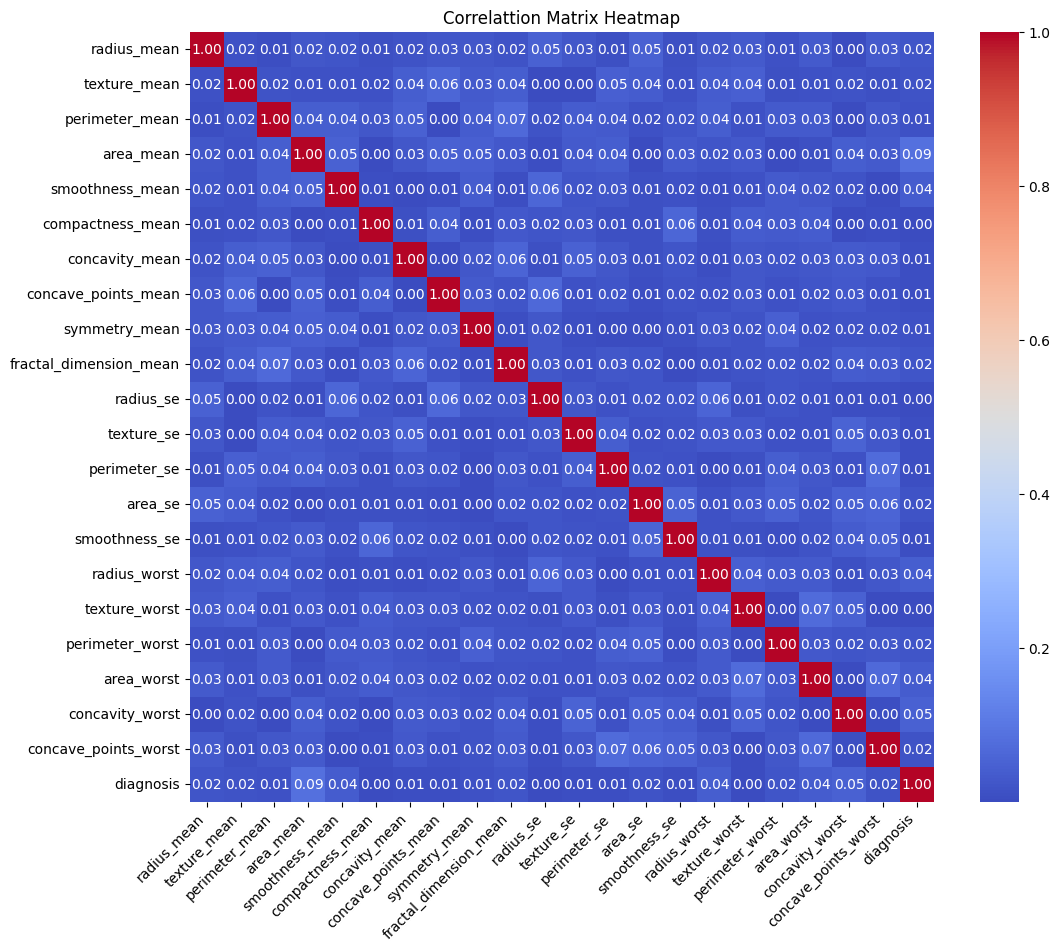

In [15]:
# Data Visualization 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.xticks(rotation=45, ha='right')
plt.title('Correlattion Matrix Heatmap')
plt.show()

In [16]:
# Using Plotly Express 
import plotly.express as px

# Create a long-form dataframe for plotly

corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Feature 1', 'Feature 2', 'Correlation']

# To make more interactive Heatmap with plotly.express

fig = px.imshow(
    corr_matrix, 
    text_auto = '.2f',
    aspect = 'auto',      # resize automatically to fit the screen size
    color_continuous_scale = 'Viridis',
    zmin = -1, zmax=1,
    title= 'Correlation  Matrix HeatMap (Interactive way)'

)
fig.update_layout(

    width = 1000,
    height = 800,
    xaxis_title = 'Features',
    yaxis_title = 'Features'
)


import plotly.io as pio
pio.renderers.default = "browser"
fig.show()

In [17]:
# Low variance 
from sklearn.feature_selection import VarianceThreshold

# Set the threshold variane at 0.01
threshold = 0.01

# Initialize Variance Threshold
selector = VarianceThreshold(threshold=threshold)

# Fit on the dataset 
selector.fit(df_filtered)

# Features with low variance
low_variance_features = df_filtered.columns[~selector.get_support()]
print('Features with low variance (to_drop): ', list(low_variance_features))

# Drop the variance features
df_low_variance_filtered = df_filtered.drop(columns=low_variance_features)
print('\nOriginal Shape: ', df_filtered.shape)
print('\nShape after droping low_variance_features: ', df_low_variance_filtered.shape)


Features with low variance (to_drop):  ['smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'smoothness_se', 'concavity_worst', 'concave_points_worst']

Original Shape:  (1200, 22)

Shape after droping low_variance_features:  (1200, 12)


In [18]:
# Buni Plotly Expressda ifodalaganda
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Har bir ustunni varianceni hisoblash
variances = df[numeric_cols].var()

# Chegara (lmit) qo'yish 
threshold = 0.01

# Low Variance Features
low_variance_features = variances[variances<threshold].index.tolist()

var_df = pd.DataFrame({     # yangi jadval yasayapti
    'Feature': variances.index, # ustun nomlari masalan: ['age', 'height' ..]
    'Variance': variances.values,    # Qiymatlari masalan: [20.5, 500, 0.002...]
    'LowVariance': ['Yes' if f in low_variance_features else 'No' for f in variances.index] # bu yerda avval if ni birinchi keyin esa for loopni qilinar ekan

})

fig = px.bar(
    var_df,
    x = 'Feature',  # x-o'qi ustunlar 
    y = 'Variance', # y-o'qi variance
    color = 'LowVariance',  # rang 'Yes' qizil, 'No' ko'k
    color_discrete_map = {'Yes': 'red', 'No': 'blue'},  # Rangni o'zimiz belgilaymiz
    text = 'Variance',  # ustiga son yozadi
    title='Feature Variance...'   # Grafik nomi
 )

fig.update_layout(
    xaxis_tickangle=-45,   # Yozuvni o'ng tomonga qiyshaytiradi
    width = 1000,
    height = 600

 )

fig.show()

In [19]:
# Natijasi faqat browserda chiqayapti, harakat qildim ammo VS Codedda chiqara olmadim.
# Noqulayliklar uchun uzur so'rayman.

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   radius_mean             1200 non-null   float64
 1   texture_mean            1200 non-null   float64
 2   perimeter_mean          1200 non-null   float64
 3   area_mean               1200 non-null   float64
 4   smoothness_mean         1200 non-null   float64
 5   compactness_mean        1200 non-null   float64
 6   concavity_mean          1200 non-null   float64
 7   concave_points_mean     1200 non-null   float64
 8   symmetry_mean           1200 non-null   float64
 9   fractal_dimension_mean  1200 non-null   float64
 10  radius_se               1200 non-null   float64
 11  texture_se              1200 non-null   float64
 12  perimeter_se            1200 non-null   float64
 13  area_se                 1200 non-null   float64
 14  smoothness_se           1200 non-null   float64
 15

In [21]:
# Separate Features (X) and Target (Y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)
print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

Training Set Shape: (960, 21)
Testing Set Shape: (240, 21)


In [23]:
# Feature Scaling 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Fit on training set only to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# # Convert back to DataFrame for better interpretability later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [24]:
# LogiisticRegression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Embedded methods

In [25]:
 
from sklearn.linear_model import LassoCV

# Fit on training set only to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

lasso = LassoCV(cv=5, random_state=42).fit(X_train_scaled, y_train)
importance = np.abs(lasso.coef_)

selected_features = X.columns[importance > 0]

print('Selected features using Lasso (non-zero coefficient): ')
print(selected_features.tolist())

Selected features using Lasso (non-zero coefficient): 
['area_mean']


In [26]:
# Shunda bizda eng muhim ustun 'area_mean' ekan 
# Modelni soddaashtirish uchun 
# Overfitting kamayadi: Kamroq faetue kamroq oise
# Taregt asosan 'area_mean' ga bog'langan ekan

In [27]:
y_pred_lr = lr.predict(X_test_scaled)

/Users/murodjongafforov/Desktop/Model Building /2-oy-Model Building /10-dars/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [28]:
print(classification_report(y_test, y_pred_lr, target_names=['Benign: (0)', 'Malignant (1)']))

               precision    recall  f1-score   support

  Benign: (0)       0.51      0.60      0.55       122
Malignant (1)       0.49      0.40      0.44       118

     accuracy                           0.50       240
    macro avg       0.50      0.50      0.49       240
 weighted avg       0.50      0.50      0.49       240



In [29]:
# Random Forest Classifier

rfc = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rfc.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
y_pred_rfc = rfc.predict(X_test)
print(classification_report(y_test, y_pred_rfc, target_names=['Benign: (0)', 'Malignant (1)']))

               precision    recall  f1-score   support

  Benign: (0)       0.52      0.66      0.58       122
Malignant (1)       0.52      0.38      0.44       118

     accuracy                           0.52       240
    macro avg       0.52      0.52      0.51       240
 weighted avg       0.52      0.52      0.51       240



In [31]:
# Support Vector Machine Classifier
svc = SVC(kernel='rbf', random_state=42, C=1.0)
svc.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [32]:
y_pred_svc = svc.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svc, target_names=['Benign (0)', 'Malignant (1)']))

               precision    recall  f1-score   support

   Benign (0)       0.51      0.49      0.50       122
Malignant (1)       0.49      0.51      0.50       118

     accuracy                           0.50       240
    macro avg       0.50      0.50      0.50       240
 weighted avg       0.50      0.50      0.50       240



# Wrapper Method

In [33]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Separate Features (X) and Target (Y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

model = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)
selected_features = X.columns[rfe.support_]

print('Selected features: ', selected_features)

Selected features:  Index(['area_mean', 'symmetry_mean', 'radius_se', 'area_se',
       'concave_points_worst'],
      dtype='str')


# Best Models after doing feature selction methods


In [1]:
from tabulate import tabulate

In [ ]:
results = [
    ['Logistic Regression', 0.50],
    ['Random Forest Classifier', 0.53],
    ['Support Vector Classifier', 0.50]
]
headers = ['Models', 'Accuracy']
table = tabulate(results, headers=headers, tablefmt='grid', floatfmt='.2f')
print('Log Transformation va Feature Selection keyin ham deyarli bir hil natija:')
print(table)

Log Transformation va Feature Selection keyin ham deyarli bir hil natija:
+---------------------------+------------+
| Models                    |   Accuracy |
+===========================+============+
| Logistic Regression       |       0.50 |
+---------------------------+------------+
| Random Forest Classifier  |       0.53 |
+---------------------------+------------+
| Support Vector Classifier |       0.50 |
+---------------------------+------------+


In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn

zsh:1: permission denied: /Users/murodjongafforov/Desktop/Model


In [4]:
import sys
!{sys.executable} -m pip install scikit-learn tabulate

zsh:1: permission denied: /Users/murodjongafforov/Desktop/Model


In [6]:

# Joblib orqali modelni saqlayman
from joblib import dump, load
dump(rfc, 'random_forest_best_model.joblib')


['random_forest_best_model.joblib']